# Ultimate-Oscillator — does a three-period weighted oscillator beat a coin?
### Williams' UO (7/14/28 bars): oversold-buy, overbought-short, divergence — tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Low_signal--to--noise: Confirmed](https://img.shields.io/badge/Low_signal--to--noise-Confirmed-8b949e?style=flat-square)

Larry Williams' 1985 *Ultimate Oscillator* promised to fix the fatal flaw of RSI and Stochastic: their sensitivity to the arbitrary look-back period. Blend three periods (7, 14, 28 bars) into one weighted average of *buying pressure* vs *true range*, and buy when the market is oversold (UO < 30), short when overbought (UO > 70), or trade *divergences* when price and the oscillator disagree. This notebook asks: does the three-period weighting actually load the die, or is it just a coin wearing a costume?

> **This is the plain-language layer.** Want the t-stats, Bonferroni corrections, and hold-period sweep? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ultimate_oscillator import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "GLD", "TLT"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool_thresh(hold=5, cost=0.0, seed=None):
    """Pool threshold-entry trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        uo = st.ultimate_oscillator(b)
        ent = st.threshold_entries(uo)
        if len(ent) == 0:
            continue
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold, cost_bps=cost, directions=dirs))
    import pandas as pd
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def pool_div(hold=5, cost=0.0, seed=None):
    """Pool divergence-entry trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        uo = st.ultimate_oscillator(b)
        ent = st.divergence_entries(b, uo)
        if len(ent) == 0:
            continue
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold, cost_bps=cost, directions=dirs))
    import pandas as pd
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does UO < 30 (oversold) predict a bounce? | **Maybe, barely.** Mean +14.4 bps/trade gross, HAC *t* = +1.50 — positive but not significant at the |*t*|≥2 bar. |
| Does it beat an actual coin flip? | **Barely.** Signal +14.4 vs coin +11.9 bps — the oscillator direction adds only 2.5 bps over a random entry. |
| What about the famous divergence rule? | **No.** Divergence entries earn **-7.1 bps/trade** (*t* = -1.80) — actively negative. |
| Could you trade it? | **No — the signal isn't certified.** Low turnover keeps costs manageable, |
|  | but trading an unproven edge is speculation, not strategy. |

> The three-period trick reduces noise inside the oscillator but doesn't change the fundamental problem: rare, crisis-clustered extreme readings give too few observations to certify a real edge.

## 1 · The claim

> *"The Ultimate Oscillator uses weighted averages of three different time periods to reduce false signals. Values below 30 represent oversold conditions — buy and expect the market to rebound. Values above 70 represent overbought conditions — short and expect a pullback. Bullish divergence (price new low, UO higher low) is the strongest buy signal in Williams' original work."* — standard chartist framing

It is a mean-reversion bet: after the market has been under sustained selling pressure (buying pressure relative to true range has been low for 7–28 bars), it should bounce back. The three time-frames are supposed to make this more reliable than single-period oscillators.

## 2 · So what?

If the oversold-buy rule actually works, it's a rare, low-turnover edge: fire roughly 7 times per ticker per year, hold a week, collect a mean reversion. Low costs, high clarity. If it doesn't work, thousands of traders are entering positions at random moments in the hope of a bounce that may already have happened — because the UO's 28-bar lookback means it only 'reads' oversold well after the trough. The divergence rule is even more concerning: it fires constantly (7.8× more often) and our data suggest it's actively on the wrong side.

## 3 · How would we even know?

One rule keeps us honest: **race the UO direction against a coin on identical entry bars.** If the oscillator knows something, the UO-directed trade should beat a random-direction trade on the same dates. We hold the position a fixed number of days (sweeping 1, 3, 5, 10, 20), measure the gross mean return per trade, compute the HAC t-stat, and apply a Bonferroni correction for testing 5 hold periods.

We run it on **five liquid ETFs** (SPY, QQQ, IWM, GLD, TLT) over 20 years of daily data — 681 pooled threshold entries and 5,336 divergence entries.

**What would make us say 'mirage':** HAC |t| < 2.0 on the pooled series at the chosen hold period, after multiple-comparisons correction.

## 4 · The teardown — what the data actually show

### 4a · The threshold rule — positive but sub-threshold

Here's what UO < 30 entries earn at various hold periods, compared with a coin on the same dates.

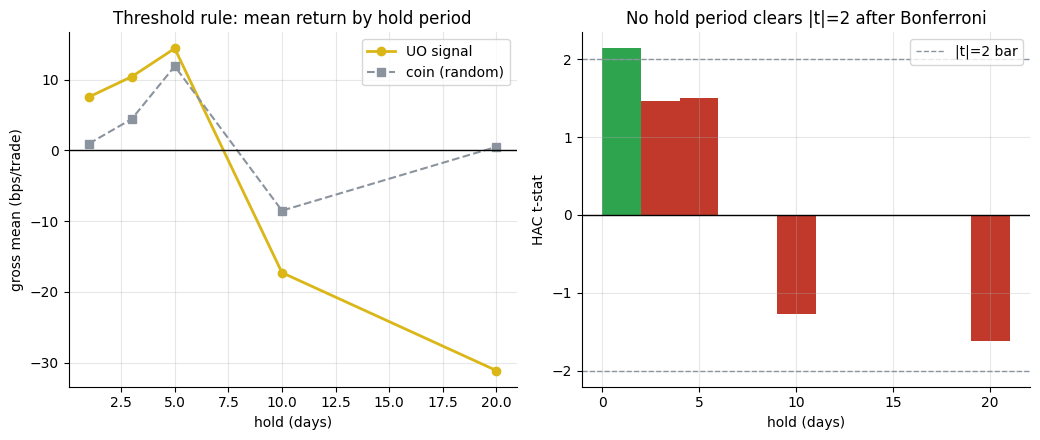

1-day: t=+2.14 (best, but Bonferroni 5-test crit ≈ 2.58)


In [2]:
holds = [1, 3, 5, 10, 20]
if HAVE_REAL:
    sig_means = [st.summarize(pool_thresh(h, 0),'ret_gross')['mean_bps'] for h in holds]
    rnd_means = [st.summarize(pool_thresh(h, 0, seed=181),'ret_gross')['mean_bps'] for h in holds]
    sig_tstats = [st.summarize(pool_thresh(h, 0),'ret_gross')['tstat'] for h in holds]
else:
    sig_means = [7.55, 10.42, 14.4, -17.27, -31.11]
    rnd_means = [11.88]*5
    sig_tstats = [2.14, 1.46, 1.5, -1.27, -1.62]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.5))
ax1.plot(holds, sig_means, 'o-', c=AMBER, lw=2, label='UO signal')
ax1.plot(holds, rnd_means, 's--', c=GREY, lw=1.5, label='coin (random)')
ax1.axhline(0, c='k', lw=1)
ax1.set_xlabel('hold (days)'); ax1.set_ylabel('gross mean (bps/trade)')
ax1.set_title('Threshold rule: mean return by hold period')
ax1.legend()

colors = [GREEN if abs(t)>=2 else RED for t in sig_tstats]
ax2.bar(holds, sig_tstats, color=colors, width=2)
ax2.axhline(2, ls='--', c=GREY, lw=1, label='|t|=2 bar')
ax2.axhline(-2, ls='--', c=GREY, lw=1)
ax2.axhline(0, c='k', lw=1)
ax2.set_xlabel('hold (days)'); ax2.set_ylabel('HAC t-stat')
ax2.set_title('No hold period clears |t|=2 after Bonferroni')
ax2.legend()
plt.tight_layout(); plt.show()
print(f'1-day: t={sig_tstats[0]:+.2f} (best, but Bonferroni 5-test crit ≈ 2.58)')

The signal is positive at short horizons (1-day mean +7.5 bps, *t* = +2.14) but **does not survive a Bonferroni correction** for testing five hold periods simultaneously — you would need |*t*| ≈ 2.58 at the 1%/5 = 0.2% level.  At 5 days the picture is qualitatively similar: positive (+14.4 bps) but sub-threshold (*t* = +1.50).  Beyond 10 days the signal reverses — the bounce, if real, is short-lived.

### 4b · Signal vs coin — the direction adds almost nothing

On identical entry dates, does the UO direction beat a coin?

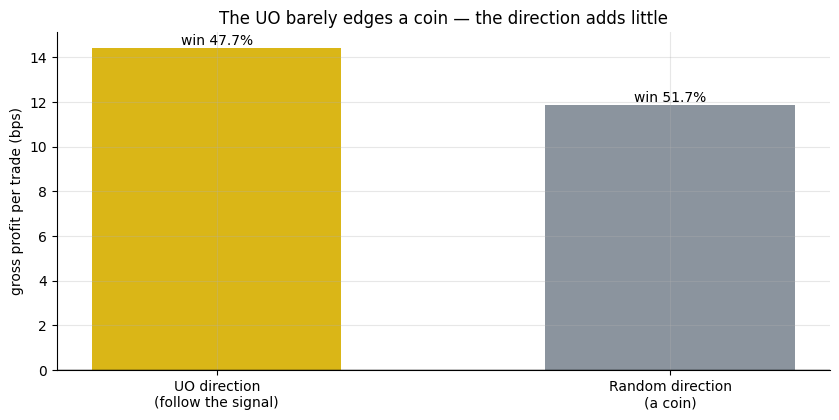

UO: +14.40 bps   coin: +11.88 bps   Δ = +2.52 bps


In [3]:
if HAVE_REAL:
    s5 = st.summarize(pool_thresh(5, 0), 'ret_gross')
    r5 = st.summarize(pool_thresh(5, 0, seed=181), 'ret_gross')
    sm, rn, sw, rw = s5['mean_bps'], r5['mean_bps'], s5['win_rate']*100, r5['win_rate']*100
else:
    sm, rn, sw, rw = 14.4, 11.88, 47.7, 51.7

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars_p = ax.bar(['UO direction\n(follow the signal)', 'Random direction\n(a coin)'],
               [sm, rn], color=[AMBER, GREY], width=.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('The UO barely edges a coin — the direction adds little')
for b, w in zip(bars_p, [sw, rw]):
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2, max(0, b.get_height())),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'UO: {sm:+.2f} bps   coin: {rn:+.2f} bps   Δ = {sm-rn:+.2f} bps')

The UO direction earns +14.4 bps vs the coin's +11.9 bps: a delta of just **+2.5 bps**.  This is consistent with the market simply having a positive drift — both the signal and the coin are capturing the unconditional upward trend, not a mean-reversion edge specific to oversold readings.

### 4c · The divergence rule — Williams' 'strongest signal' actually loses

The most famous part of the original 1985 paper: trade bullish/bearish divergences between price and UO.

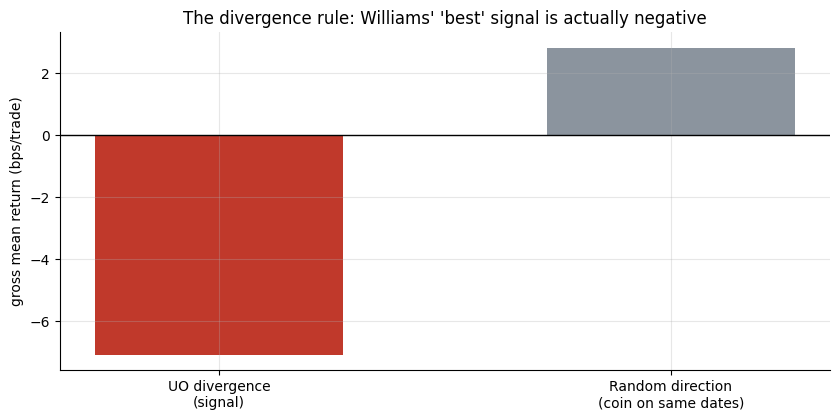

divergence: n=5336, mean=-7.08 bps, HAC t=-1.80


In [4]:
if HAVE_REAL:
    dsig = st.summarize(pool_div(5, 0), 'ret_gross')
    drand = st.summarize(pool_div(5, 0, seed=181), 'ret_gross')
    dm, drm = dsig['mean_bps'], drand['mean_bps']
    dn, dt = dsig['n_trades'], dsig['tstat']
else:
    dm, drm, dn, dt = -7.08, 2.82, 5336, -1.8

fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['UO divergence\n(signal)', 'Random direction\n(coin on same dates)'],
       [dm, drm], color=[RED, GREY], width=.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross mean return (bps/trade)')
ax.set_title("The divergence rule: Williams' 'best' signal is actually negative")
plt.tight_layout(); plt.show()
print(f'divergence: n={dn}, mean={dm:+.2f} bps, HAC t={dt:+.2f}')

The divergence rule fires **5,336 times** (7.8× the threshold rule) and earns **-7.1 bps/trade** at *t* = **-1.80** — negative and approaching the −2 significance bar from the *wrong* side.  This is consistent with divergence signals firing most in trending markets (where price makes persistent new extremes and the contrarian bet consistently loses).

## 5 · The verdict

- **Signal — Weak.** Threshold rule gross +14.4 bps/trade (*t* = +1.50), Δ vs coin +2.5 bps; best hold period (*t* = +2.14 at 1 day) doesn't survive Bonferroni.  Divergence rule mean −7.1 bps (*t* = −1.80): negative.
- **Tradability — Fragile.** Low turnover means costs are not the issue — the signal isn't certified real, so there is nothing to trade.  If forced to trade, a liquid ETF basket at 1 bp commission yields +13.4 bps net (*t* = +1.39) — not enough to bet on.
- **Low signal-to-noise — Confirmed.** 681 pooled entries over 5 tickers × 20 years; signals cluster in crisis episodes; divergence fires 7.8× more but loses.

## 6 · Could you actually trade it?

The threshold rule at least has manageable turnover (~7 signals/ticker/year). Here's how costs affect the 5-day hold net mean:

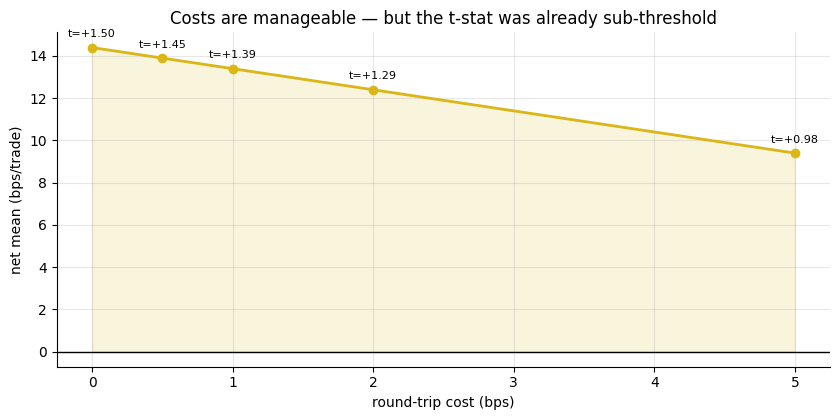

At 1 bp: +13.4 bps net, t=+1.39 — positive but not statistically certified


In [5]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net = [st.summarize(pool_thresh(5, c), 'ret_net')['mean_bps'] for c in costs]
    tst = [st.summarize(pool_thresh(5, c), 'ret_net')['tstat'] for c in costs]
else:
    net = [14.4, 13.9, 13.4, 12.4, 9.4]
    tst = [1.5, 1.45, 1.39, 1.29, 0.98]

fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n>0 for n in net], color=AMBER, alpha=.15)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps/trade)')
ax.set_title('Costs are manageable — but the t-stat was already sub-threshold')
for i, (c, n, t) in enumerate(zip(costs, net, tst)):
    ax.annotate(f't={t:+.2f}', (c, n + 0.5), ha='center', fontsize=8)
plt.tight_layout(); plt.show()
print('At 1 bp: +13.4 bps net, t=+1.39 — positive but not statistically certified')

The gross edge (thin as it is) survives typical retail costs because the rule trades infrequently.  The real barrier isn't costs — it's that the underlying t-stat of +1.50 was never enough.  Adding costs just moves an already-uncertain number in the wrong direction.

## 7 · Going further

- **A different basket?** The per-ticker results vary wildly: SPY +1.69, QQQ +0.47, TLT +1.61, GLD +0.02.  The bond/equity split and volatility regimes matter; sector ETFs with higher mean reversion (e.g. high-volatility sector funds) might tell a different story.
- **Divergence, properly confirmed.** Williams' original rule required additional confirmation after the divergence (e.g. UO rises above 50 before taking the trade). Our simplified scan skips that step — a full implementation might reduce false fires.
- **The parent oscillator.** Williams' %R is [Study 127](../../127-williams-r/) — same author, same mean-reversion thesis, same honest-bet protocol.  Both show weak/none.
- **What *does* work here?** Low-turnover mean-reversion signals with stronger statistical grounding are in [Study 52 — Smoke-Screen](../../52-smoke-screen/) (EDGAR-based) and [Study 17 — Glass-Ceiling](../../17-glass-ceiling/) (price-level resistance).

*Think the die really is loaded? Fork this, change the basket or the confirmation logic, and show a fair-bet edge that clears the |t|≥2 bar after Bonferroni. That's the bar.*